# Build mini-iWildCam

**Part A** — build & save mini metadata (runs now, no images, no network needed)  
**Part B** — download only the mini images (needs ~12 GB network, ~3 GB disk)

### Why not just use `wilds` download?
The default WILDS downloader saves a 12 GB archive *and* extracts ~20 GB of images simultaneously — ~32 GB peak disk. Part B streams the archive directly over the network and only writes the files we need to disk.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.insert(0, str(Path.cwd().parent.parent))
from iwildcam.config import CONFIG

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

RESULTS   = Path('../results')
RESULTS.mkdir(exist_ok=True)

DATA_DIR  = Path(CONFIG['data_dir'])
META_FULL = DATA_DIR / 'iwildcam_v2.0' / 'metadata.csv'
MINI_DIR  = DATA_DIR / 'iwildcam_mini'
MINI_META = MINI_DIR / 'metadata.csv'
MINI_DIR.mkdir(parents=True, exist_ok=True)

assert META_FULL.exists(), f'Run download_metadata.py first. Expected: {META_FULL}'
print('Full metadata found.')

Full metadata found.


---
## Part A — Build mini metadata

### A1. Parameters

In [2]:
MIN_TRAIN    = 100    # min images in train to keep a class
MIN_OOD_TEST = 20     # min images in OOD test to keep a class
TARGET_TOTAL = 50_000 # total images across all splits
ALPHA        = 0.8    # imbalance compression: 1.0 = preserve exactly, 0.0 = fully balanced
SEED         = 42

### A2. Load full metadata

In [3]:
df = pd.read_csv(META_FULL)
print(f'{len(df):,} rows | splits: {df["split"].value_counts().to_dict()}')

203,029 rows | splits: {'train': 129809, 'test': 42791, 'val': 14961, 'id_test': 8154, 'id_val': 7314}


### A3. Class filtering

In [4]:
train_counts    = df[df['split'] == 'train'].groupby('y').size()
ood_test_counts = df[df['split'] == 'test' ].groupby('y').size()

valid_classes = (
    set(train_counts   [train_counts    >= MIN_TRAIN   ].index) &
    set(ood_test_counts[ood_test_counts >= MIN_OOD_TEST].index)
)

df_filtered = df[df['y'].isin(valid_classes)].copy()

print(f'Classes : {df["y"].nunique()} → {len(valid_classes)}')
print(f'Images  : {len(df):,} → {len(df_filtered):,}')
print(f'Removed : {df["y"].nunique() - len(valid_classes)} classes '
      f'({len(df) - len(df_filtered):,} images)')

Classes : 182 → 53
Images  : 203,029 → 191,555
Removed : 129 classes (11,474 images)


### A4. Subsampling to target size

In [5]:
def subsample_split(grp: pd.DataFrame, target: int, alpha: float, seed: int) -> pd.DataFrame:
    """Sample ~target rows; per-class weights = count^alpha (mild imbalance compression)."""
    if len(grp) <= target:
        return grp
    class_counts = grp.groupby('y').size()
    weights      = class_counts.pow(alpha)
    targets_cls  = (weights / weights.sum() * target).round().clip(lower=1).astype(int)
    parts = []
    for cls, n_target in targets_cls.items():
        cls_grp = grp[grp['y'] == cls]
        parts.append(cls_grp.sample(n=min(n_target, len(cls_grp)), random_state=seed))
    return pd.concat(parts)

split_sizes   = df_filtered.groupby('split').size()
split_targets = (split_sizes / split_sizes.sum() * TARGET_TOTAL).round().astype(int)

print('Per-split targets:')
for s, t in split_targets.items():
    actual = split_sizes[s]
    action = f'keep all {actual:,}' if actual <= t else f'sample {t:,} from {actual:,}'
    print(f'  {s:10s}: {action}')

Per-split targets:
  id_test   : sample 1,970 from 7,549
  id_val    : sample 1,831 from 7,014
  test      : sample 10,932 from 41,882
  train     : sample 31,898 from 122,203
  val       : sample 3,369 from 12,907


In [6]:
parts = []
for split_name, grp in df_filtered.groupby('split'):
    parts.append(subsample_split(grp, int(split_targets[split_name]), ALPHA, SEED))

df_mini = pd.concat(parts).reset_index(drop=True)
print(f'Mini dataset: {len(df_mini):,} images, {df_mini["y"].nunique()} classes')

Mini dataset: 50,001 images, 53 classes


### A5. Save mini metadata

In [7]:
df_mini.to_csv(MINI_META, index=False)
size_mb = MINI_META.stat().st_size / 1e6
print(f'Saved → {MINI_META}  ({size_mb:.1f} MB)')

Saved → c:\Users\tomma\Desktop\TRANSFER LEARNING\data\iwildcam_mini\metadata.csv  (8.6 MB)


### A6. Plots — full vs mini

In [8]:
# ── Split overview table ──────────────────────────────────────────────────────
def split_summary(frame):
    rows = []
    for split, grp in frame.groupby('split'):
        rows.append({'split': split, 'samples': len(grp),
                     'classes': grp['y'].nunique(),
                     'locations': grp['location_remapped'].nunique()})
    return pd.DataFrame(rows).set_index('split')

full_summary = split_summary(df)
mini_summary = split_summary(df_mini)
comparison   = pd.concat([full_summary, mini_summary], axis=1,
                          keys=['full', 'mini'])
print(comparison.to_string())

           full                      mini                  
        samples classes locations samples classes locations
split                                                      
id_test    8154      87       164    1971      49       141
id_val     7314      71       146    1832      47       125
test      42791     102        48   10932      53        45
train    129809     182       243   31893      53       231
val       14961      75        32    3373      45        32


Imbalance ratio  full: 48021x   mini: 141x


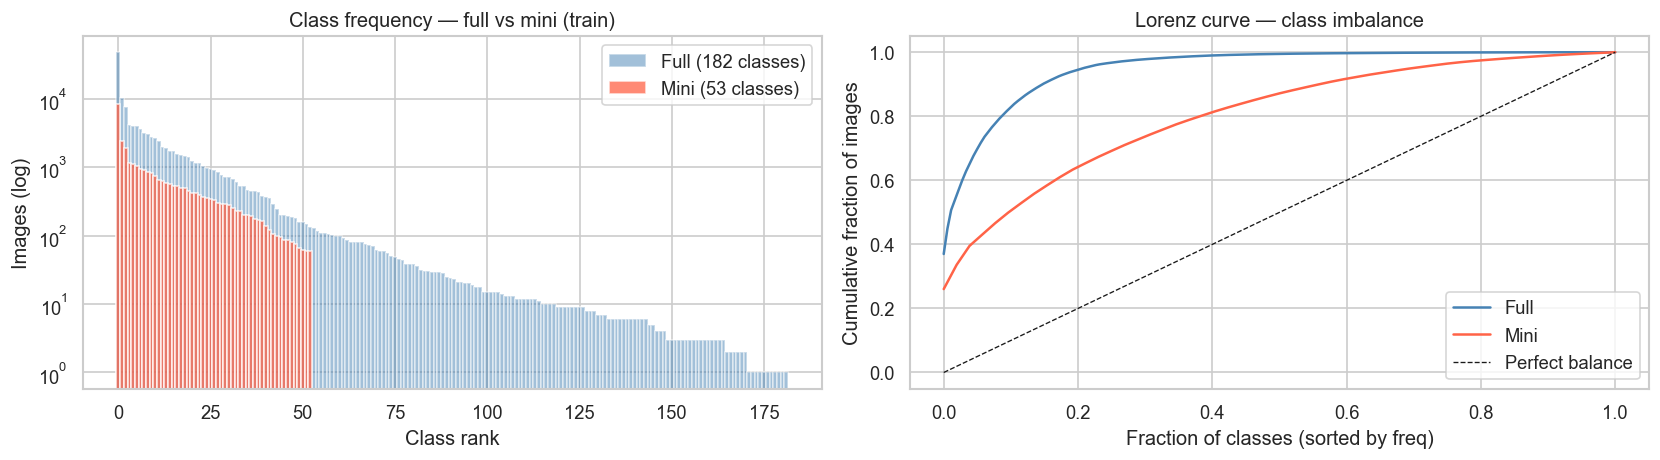

In [9]:
# ── Class distribution + Lorenz curve ────────────────────────────────────────
train_full = df[df['split'] == 'train']
train_mini = df_mini[df_mini['split'] == 'train']

cc_full = train_full['y'].value_counts().sort_values(ascending=False)
cc_mini = train_mini['y'].value_counts().sort_values(ascending=False)

ratio_full = cc_full.iloc[0] / cc_full.iloc[-1]
ratio_mini = cc_mini.iloc[0] / cc_mini.iloc[-1]
print(f'Imbalance ratio  full: {ratio_full:.0f}x   mini: {ratio_mini:.0f}x')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(range(len(cc_full)), cc_full.values, width=1.0,
            color='steelblue', alpha=0.5, label=f'Full ({len(cc_full)} classes)')
axes[0].bar(range(len(cc_mini)), cc_mini.values, width=1.0,
            color='tomato', alpha=0.75, label=f'Mini ({len(cc_mini)} classes)')
axes[0].set_yscale('log')
axes[0].set_xlabel('Class rank')
axes[0].set_ylabel('Images (log)')
axes[0].set_title('Class frequency — full vs mini (train)')
axes[0].legend()

cum_full = np.cumsum(cc_full.values) / cc_full.sum()
cum_mini = np.cumsum(cc_mini.values) / cc_mini.sum()
axes[1].plot(np.linspace(0, 1, len(cum_full)), cum_full, color='steelblue', label='Full')
axes[1].plot(np.linspace(0, 1, len(cum_mini)), cum_mini, color='tomato',    label='Mini')
axes[1].plot([0, 1], [0, 1], 'k--', lw=0.8, label='Perfect balance')
axes[1].set_xlabel('Fraction of classes (sorted by freq)')
axes[1].set_ylabel('Cumulative fraction of images')
axes[1].set_title('Lorenz curve — class imbalance')
axes[1].legend()

plt.tight_layout()
plt.savefig(RESULTS / 'class_imbalance_comparison.png', bbox_inches='tight')
plt.show()

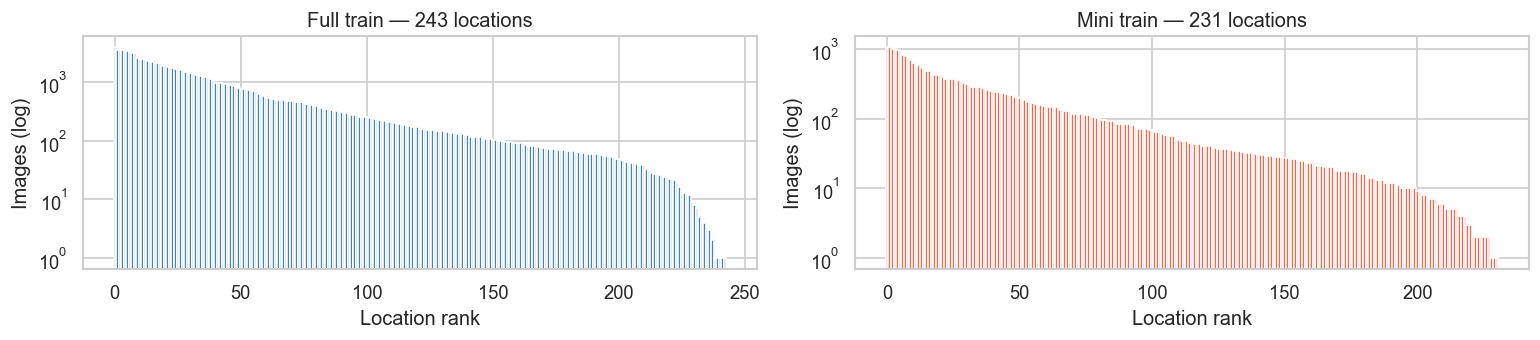

In [10]:
# ── Location coverage ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 3))
for ax, frame, label, color in [
    (axes[0], train_full, 'Full train', 'steelblue'),
    (axes[1], train_mini, 'Mini train', 'tomato'),
]:
    lc = frame['location_remapped'].value_counts().sort_values(ascending=False)
    ax.bar(range(len(lc)), lc.values, width=1.0, color=color)
    ax.set_yscale('log')
    ax.set_title(f'{label} — {len(lc)} locations')
    ax.set_xlabel('Location rank')
    ax.set_ylabel('Images (log)')

plt.tight_layout()
plt.savefig(RESULTS / 'location_comparison.png', bbox_inches='tight')
plt.show()

In [11]:
# ── OOD domain overlap preserved? ────────────────────────────────────────────
mini_train_locs = set(df_mini[df_mini['split'] == 'train']['location_remapped'])
print('Mini — overlap with train locations:')
for name, key in [('id_val','id_val'), ('ood_val','val'), ('id_test','id_test'), ('ood_test','test')]:
    s = set(df_mini[df_mini['split'] == key]['location_remapped'])
    print(f'  {name:10s}: {len(s):3d} locations | shared with train: {len(s & mini_train_locs)}')

Mini — overlap with train locations:
  id_val    : 125 locations | shared with train: 125
  ood_val   :  32 locations | shared with train: 0
  id_test   : 141 locations | shared with train: 140
  ood_test  :  45 locations | shared with train: 0


---
## Part B — Download mini images

**Requirements:**
- ~12 GB network transfer (streams without saving the archive)
- ~3 GB free disk space (only selected images are written)
- Time: 30–90 min depending on connection

**How it works:**  
The archive is streamed directly from Codalab. For each entry in the tar, we check if that filename is in our mini-set. If yes, we write it. If no, we skip it. The archive itself is never saved to disk.

In [12]:
import shutil

# Check free disk space before starting
free_gb = shutil.disk_usage(DATA_DIR).free / 1e9
print(f'Free disk space: {free_gb:.1f} GB')
if free_gb < 4:
    print('WARNING: less than 4 GB free — consider freeing space before running Part B')
else:
    print('Disk space looks OK.')

Free disk space: 781.5 GB
Disk space looks OK.


In [13]:
import tarfile
import requests
from io import RawIOBase
from tqdm.notebook import tqdm

BUNDLE_URL = (
    'https://worksheets.codalab.org/rest/bundles/'
    '0x6313da2b204647e79a14b468131fcd64/contents/blob/'
)
IMG_DIR = MINI_DIR / 'train'
IMG_DIR.mkdir(exist_ok=True)

# Files we need (set for O(1) lookup)
needed = set(df_mini['filename'].values)
already_done = {p.name for p in IMG_DIR.glob('*.jpg')}
to_fetch = needed - already_done
print(f'Images needed   : {len(needed):,}')
print(f'Already on disk : {len(already_done):,}')
print(f'To download     : {len(to_fetch):,}')

if not to_fetch:
    print('Nothing to download — all images present.')

Images needed   : 50,001
Already on disk : 0
To download     : 50,001


In [14]:
class _IterStream(RawIOBase):
    """Wraps a requests chunk-iterator into a file-like object for tarfile."""
    def __init__(self, iterator):
        self._iter = iterator
        self._buf  = b''

    def readable(self):
        return True

    def readinto(self, b):
        n = len(b)
        while len(self._buf) < n:
            try:
                self._buf += next(self._iter)
            except StopIteration:
                break
        out, self._buf = self._buf[:n], self._buf[n:]
        b[:len(out)] = out
        return len(out)


def download_mini_images(bundle_url, to_fetch, img_dir, chunk_mb=4):
    chunk = chunk_mb * 1 << 20
    saved = skipped = 0

    with requests.get(bundle_url, stream=True, timeout=120) as r:
        r.raise_for_status()
        total_bytes = int(r.headers.get('content-length', 0))
        stream = _IterStream(r.iter_content(chunk_size=chunk))

        with tarfile.open(fileobj=stream, mode='r|gz') as tar:
            pbar = tqdm(total=total_bytes, unit='B', unit_scale=True,
                        desc='Streaming archive')
            for member in tar:
                fname = Path(member.name).name
                pbar.update(member.size)
                if fname not in to_fetch:
                    skipped += 1
                    continue
                f = tar.extractfile(member)
                if f:
                    (img_dir / fname).write_bytes(f.read())
                    saved += 1
                    if saved % 500 == 0:
                        pbar.set_postfix(saved=saved)
            pbar.close()

    return saved, skipped


if to_fetch:
    saved, skipped = download_mini_images(BUNDLE_URL, to_fetch, IMG_DIR)
    print(f'Done. Saved: {saved:,}  Skipped: {skipped:,}')
    disk_used = sum(p.stat().st_size for p in IMG_DIR.glob('*.jpg')) / 1e9
    print(f'Images on disk: {disk_used:.2f} GB')

Streaming archive: 0.00B [00:00, ?B/s]

Done. Saved: 50,001  Skipped: 167,645
Images on disk: 2.77 GB
